# 06 — DSP: kiểm định khối I/Q và so sánh đường bao

**Hai sản phẩm duy nhất** (mục 4 của giai đoạn 1):

1. `outputs/tables/06_iq_phase_amplitude.csv` — lệch pha và tỉ số biên độ Q trên I của khối tạo I/Q, kèm độ nghiêng biên độ, đo tại các tần số trong dải 2300–3800 Hz.
2. `outputs/figures/06_envelope_waveform.png` — dạng sóng đường bao của 3 phương pháp.

Notebook này **không** dùng `profiling.py` và **không** dùng `measure_band.py`. Phép đo pha/biên độ trước đây nằm trong `measure_band.py` giờ đặt ngay ở cell dưới, nên nó có vết trong notebook và xuất ra bảng dùng được cho báo cáo.

MACC, SRAM và ngân sách thời gian thực thuộc mục 2.3 (benchmark trên STM32F4), không thuộc giai đoạn 1.

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter

from common import io_utils, dsp, config as cfg
from common.pipeline import pick_file

In [12]:
OUTPUT_DIR = Path('./outputs')
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(TABLES_DIR / 'manifest_clean.csv')
required_manifest_cols = [
    'file_path', 'label', 'load_hp', 'fault_diameter_mils',
    'warnings', 'has_warning', 'resolved_sample_rate_hz',
]
missing = [c for c in required_manifest_cols if c not in manifest.columns]
assert not missing, f'manifest_clean thiếu cột bắt buộc: {missing}'
assert not manifest['resolved_sample_rate_hz'].isna().any(), (
    'manifest_clean còn file thiếu sampling rate thực. Chạy lại notebook 01/02.'
)
assert not manifest['warnings'].fillna('').str.contains(
    'VONG_BI_NTN|OR_NGOAI_PHAM_VI|OR_THIEU_VI_TRI|THIEU_NHAN|THIEU_TAI|'
    'DUONG_KINH_LA|NGOAI_PHAM_VI_CAM_BIEN|NGOAI_PHAM_VI_TAN_SO_KHAI_BAO|'
    'THIEU_TIN_HIEU_DE|LOI_DOC_FILE',
    regex=True,
).any(), 'manifest_clean còn file vi phạm scope đã chốt.'

with open(TABLES_DIR / 'bandpass_config.json') as fh:
    CONF = json.load(fh)

# Mọi hằng số đọc từ bandpass_config.json (notebook 03 ghi ra) — notebook này
# không gõ lại con số nào, nên không thể lệch với 04/05.
BAND_HZ = tuple(CONF['band_hz'])
LP_CUTOFF_HZ = CONF['lp_cutoff_hz']
FS = float(CONF['fs_hz'])
F_C = float(CONF['f_c_hz'])
W_C = 2.0 * np.pi * F_C / FS
SIN_WC = np.sin(W_C)
NUMTAPS = dsp.BENCHMARK_HILBERT_NUMTAPS
M_HILB = (NUMTAPS - 1) // 2

print('Dải bandpass     :', BAND_HZ, 'Hz, bậc', CONF['bandpass_order'])
print('Tần số trung tâm :', F_C, 'Hz   (fs/4 =', FS / 4, 'Hz)')
print('Lowpass envelope :', LP_CUTOFF_HZ, 'Hz, bậc', CONF['lowpass_order'])
print('FIR Hilbert      :', NUMTAPS, 'tap, trễ nhóm', M_HILB, 'mẫu')

Dải bandpass     : (2300, 3800) Hz, bậc 4
Tần số trung tâm : 3050.0 Hz   (fs/4 = 3000.0 Hz)
Lowpass envelope : 750.0 Hz, bậc 2
FIR Hilbert      : 65 tap, trễ nhóm 32 mẫu


## 4a. Bảng đo lệch pha và tỉ số biên độ của khối tạo I/Q

Phép đo tách làm hai phần vì hai câu hỏi khác nhau.

**Phần pha** đo trên sin thuần và **bỏ qua bandpass**. Bandpass là khâu dùng chung cho cả ba phương pháp nên nó không sinh ra khác biệt nào giữa chúng; thứ cần đo là riêng khối sinh cặp trực giao. Cài đặt lấy đúng từ `dsp.py`:

- **Hybrid**: `I[n] = x[n-1]`, `Q[n] = (x[n] - x[n-2]) / (2·sin ω_c)` — bước 2 của `dsp.hybrid_envelope`.
- **FIR Hilbert**: `Q` = FIR 65 tap, `I` = x trễ đúng 32 mẫu — bước 2 của `dsp.hilbert_envelope_fir`.
- **Square-Law**: **không có khối I/Q**. `LP(x²)` không sinh cặp trực giao nào, nên hai cột pha và tỉ số Q trên I bỏ trống. Đây là một kết quả, không phải thiếu dữ liệu.
- **Hybrid (bản cũ)**: sai phân lùi bậc 1, giữ lại làm đối chứng cho phần đã sửa.

**Phần độ nghiêng biên độ** đo được cho cả ba, bằng tín hiệu AM có đường bao biết trước: `x = (1 + m·cos 2π f_m t)·sin 2π f_c t` với m = 0.5, f_m = 100 Hz, quét f_c qua dải. Chiếu đường bao thu được lên f_m để lấy biên độ, rồi chuẩn theo giá trị tại tâm dải — nên độ nghiêng bằng 1.000 tại f_c và cho thấy mức tụt về hai mép. Chuẩn theo chính mỗi phương pháp nên cột này so chéo được dù Square-Law có đơn vị bình phương.

In [13]:
FREQS_HZ = np.arange(BAND_HZ[0], BAND_HZ[1] + 1.0, 250.0)
N_PROBE = 48000       # 4 s @ 12 kHz -> mọi tần số dò có số chu kỳ nguyên
SKIP = 1024           # bỏ transient của các bộ lọc nhân quả
M_AM = 0.5            # độ sâu điều biên
F_M = 100.0           # tần số điều biên, nằm trong dải lowpass envelope

def phasor(sig, f, fs, skip=SKIP):
    t_all = np.arange(len(sig)) / fs
    s = np.asarray(sig, dtype=np.float64)[skip:]
    tt = t_all[skip:]
    re = 2.0 * np.mean(s * np.sin(2.0 * np.pi * f * tt))
    im = 2.0 * np.mean(s * np.cos(2.0 * np.pi * f * tt))
    return re + 1j * im

def iq_hybrid(x):
    i_ch = np.zeros_like(x)
    q_ch = np.zeros_like(x)
    i_ch[1:] = x[:-1]
    q_ch[2:] = (x[2:] - x[:-2]) / (2.0 * SIN_WC)
    return i_ch, q_ch

def iq_hilbert(x):
    h = dsp.design_fir_hilbert(NUMTAPS)
    q_ch = np.asarray(lfilter(h, [1.0], x), dtype=np.float64)
    i_ch = np.zeros_like(x)
    i_ch[M_HILB:] = x[:len(x) - M_HILB]
    return i_ch, q_ch

def env_squarelaw(x):
    return dsp.square_law_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)

def env_hilbert(x):
    return dsp.hilbert_envelope_fir(x, FS, band=BAND_HZ, numtaps=NUMTAPS,
                                    lp_cutoff=LP_CUTOFF_HZ)

def env_hybrid(x):
    return dsp.hybrid_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)

def env_hilbert_offline(x):
    # [CHỈ THAM CHIẾU] scipy.signal.hilbert theo khối (phi nhân quả, FFT),
    # không chạy được trên MCU. Dùng làm "trần trên" đối chứng độ chính xác
    # cho 3 phương pháp nhân quả ở trên - đúng ý tưởng gốc của đề cương.
    return dsp.hilbert_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)

VARIANTS = [
    ('Hybrid (sai phan trung tam)', iq_hybrid, env_hybrid, 'x'),
    ('FIR Hilbert (65 tap)', iq_hilbert, env_hilbert, 'x'),
    ('Square-Law', None, env_squarelaw, 'x^2'),
    # Không có khối I/Q nhân quả để đo pha: scipy.hilbert xử lý theo khối
    # FFT trên toàn tín hiệu, không tồn tại khái niệm "lệch pha I/Q theo
    # mẫu". Chỉ đo được độ nghiêng biên độ (do_nghieng) để so cùng thang.
    ('Hilbert FFT (offline, doi chung)', None, env_hilbert_offline, 'x'),
]

t = np.arange(N_PROBE) / FS
rows = []
for name, iq_fn, env_fn, unit in VARIANTS:
    for f in FREQS_HZ:
        if iq_fn is None:
            ratio = np.nan
            phase = np.nan
            phase_err = np.nan
        else:
            i_ch, q_ch = iq_fn(np.sin(2.0 * np.pi * f * t))
            r = phasor(q_ch, f, FS) / phasor(i_ch, f, FS)
            ratio = float(abs(r))
            phase = float(np.degrees(np.angle(r)))
            # Hybrid cho Q lệch +90 so với I; FIR Hilbert (cách cài đặt này)
            # cho Q lệch -90 - quy ước dấu tự nhiên khác nhau của hai cách
            # dựng I/Q, không phải lỗi. Đo sai số so với mốc GẦN NHẤT
            # (+90 hoặc -90), nếu không sẽ ra sai số ảo ~180 cho dòng lệch mốc.
            phase_ref = 90.0 if abs(phase - 90.0) <= abs(phase + 90.0) else -90.0
            phase_err = phase - phase_ref
            
        x_am = (1.0 + M_AM * np.cos(2.0 * np.pi * F_M * t)) * np.sin(2.0 * np.pi * f * t)
        amp = float(abs(phasor(env_fn(x_am), F_M, FS)))
        
        rows.append({'dsp': name,
                     'f_hz': float(f),
                     'ti_so_Q_tren_I': ratio,
                     'pha_do': phase,
                     'sai_so_pha_do': phase_err,
                     'bien_do_AM': amp,
                     'don_vi': unit})

iq_df = pd.DataFrame(rows)
center = iq_df.loc[np.isclose(iq_df['f_hz'], F_C)].set_index('dsp')['bien_do_AM']
assert len(center) == len(VARIANTS), 'thiếu điểm tâm dải để chuẩn hóa'
iq_df['do_nghieng'] = iq_df['bien_do_AM'] / iq_df['dsp'].map(center)
iq_df.to_csv(TABLES_DIR / '06_iq_phase_amplitude.csv', index=False)

def _abs_max(s):
    return np.nan if s.isna().all() else float(np.nanmax(np.abs(s)))

summary = iq_df.groupby('dsp', sort=False).agg(
    sai_so_pha_max_do=('sai_so_pha_do', _abs_max),
    Q_tren_I_min=('ti_so_Q_tren_I', 'min'),
    Q_tren_I_max=('ti_so_Q_tren_I', 'max'),
    nghieng_min=('do_nghieng', 'min'),
    nghieng_max=('do_nghieng', 'max'),
)

print('TÓM TẮT — dải', BAND_HZ, 'Hz')
print(summary.round(4).to_string())
print()
print(iq_df.round(4).to_string(index=False))

TÓM TẮT — dải (2300, 3800) Hz
                                  sai_so_pha_max_do  Q_tren_I_min  Q_tren_I_max  nghieng_min  nghieng_max
dsp                                                                                                      
Hybrid (sai phan trung tam)                  0.0024        0.9139        1.0000       0.6582          1.0
FIR Hilbert (65 tap)                         0.0024        0.9989        1.0016       0.6854          1.0
Square-Law                                      NaN           NaN           NaN       0.4861          1.0
Hilbert FFT (offline, doi chung)                NaN           NaN           NaN       0.5064          1.0

                             dsp   f_hz  ti_so_Q_tren_I   pha_do  sai_so_pha_do  bien_do_AM don_vi  do_nghieng
     Hybrid (sai phan trung tam) 2300.0          0.9339  89.9976        -0.0024      0.3369      x      0.6656
     Hybrid (sai phan trung tam) 2550.0          0.9727  90.0003         0.0003      0.4820      x      0.9524


### Cách đọc bảng
Hybrid đúng pha tuyệt đối vì `Q/I = j·sin ω / sin ω_c` là số **thuần ảo** ở mọi ω, không chỉ tại ω_c. Cái giá phải trả nằm ở biên độ: tỉ số Q trên I tỉ lệ `sin ω / sin ω_c`, bằng 1 đúng tại f_c rồi tụt về hai mép dải. Đó là đáp ứng của bộ **vi phân**, không phải Hilbert thật, nên báo cáo không được gọi phương pháp này là Hilbert. Chọn f_c = 3050 Hz sát fs/4 = 3000 Hz chính là để giảm độ nghiêng này xuống mức nhỏ nhất có thể với dải đã chốt.

## 4b. Biểu đồ so sánh dạng sóng đường bao

Ba hàng đầu vẽ **biên độ gốc**, mỗi phương pháp một trục y riêng theo đơn vị thật của nó — Square-Law trả `LP(x²)` nên đơn vị là bình phương của x, hai phương pháp kia trả biên độ. Không chồng chung một trục được vì hai thang lệch nhiều bậc độ lớn. Nền xám là tín hiệu thô để thấy đường bao bám theo cụm xung.

Hàng cuối là bản **chồng chuẩn hóa theo max**, chỉ để so hình dạng và pha. Biên độ ở hàng này đã bị bỏ, nên không đọc bất kỳ kết luận nào về mức tín hiệu từ nó.

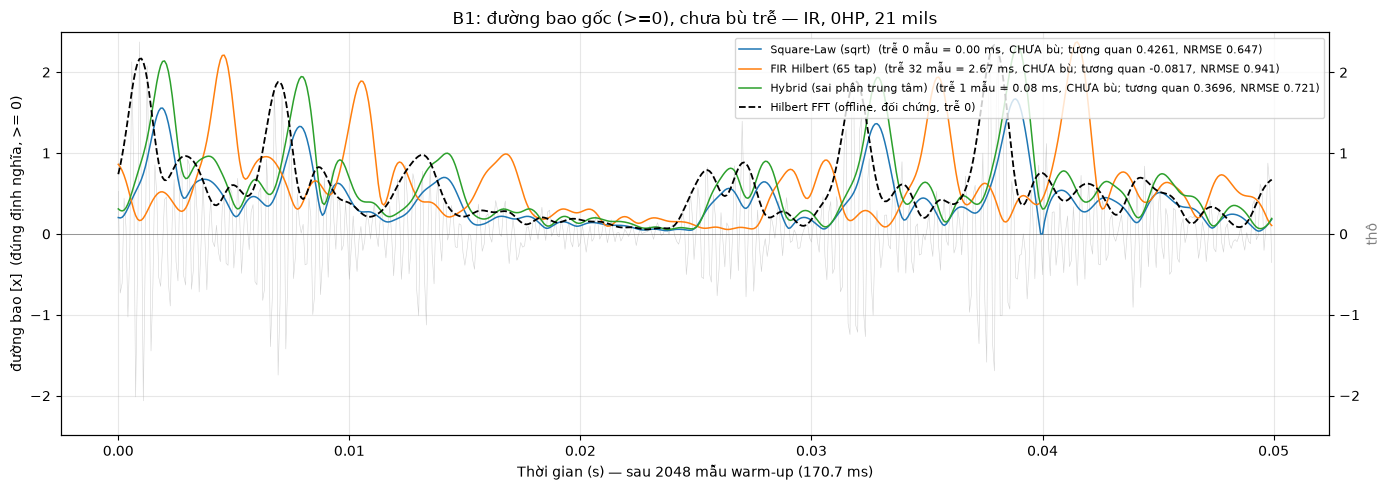

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0           0      1.6695     0.53344      0.4261   0.647
FIR Hilbert (65 tap)                32    0.055412      2.3732     0.75359     -0.0817   0.941
Hybrid (sai phân trung tâm)          1    0.055557      2.3227     0.74924      0.3696   0.721


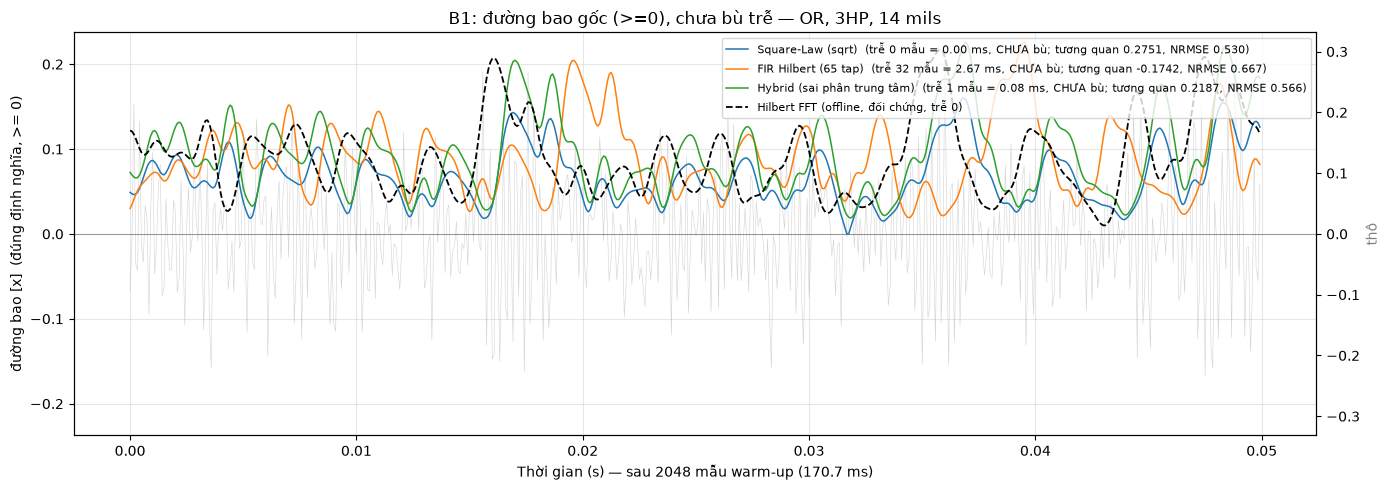

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0           0     0.16027    0.074739      0.2751   0.530
FIR Hilbert (65 tap)                32    0.019033      0.2262    0.098036     -0.1742   0.667
Hybrid (sai phân trung tâm)          1    0.018777     0.22547     0.10399      0.2187   0.566


[('Square-Law (sqrt)',
  0,
  array([0.0489636 , 0.0471415 , 0.04636924, 0.04690499, 0.04938686,
         0.05364759, 0.05943268, 0.06628686, 0.07283128, 0.07901255,
         0.08343342, 0.0859702 , 0.08659551, 0.08467735, 0.08155647,
         0.07716588, 0.07290373, 0.07034686, 0.06961369, 0.07197813,
         0.0760987 , 0.08124841, 0.08641729, 0.090335  , 0.09280575,
         0.09311515, 0.09142899, 0.087836  , 0.08266749, 0.07654203,
         0.06995207, 0.06377652, 0.05861557, 0.05531386, 0.05418884,
         0.05492719, 0.0571781 , 0.05953131, 0.06161686, 0.06258386,
         0.0620454 , 0.06051405, 0.05766715, 0.05531088, 0.05418775,
         0.05601333, 0.0617891 , 0.07015953, 0.08064577, 0.09078893,
         0.09959307, 0.10579725, 0.10833475, 0.10725574, 0.10217175,
         0.09379744, 0.08299198, 0.07068653, 0.05846701, 0.04735207,
         0.03786475, 0.0305049 , 0.02439134, 0.01927371, 0.01830581,
         0.02178861, 0.03076691, 0.04207688, 0.05338914, 0.06464426,
      

In [14]:
# ===== Bộ máy dùng chung cho 3 cell ablation =====
METHOD_CASES = [
    ('Square-Law (sqrt)', 'square_law', 'tab:blue'),
    ('FIR Hilbert (65 tap)', 'hilbert_fir', 'tab:orange'),
    ('Hybrid (sai phân trung tâm)', 'hybrid', 'tab:green')
]

FS_COL = 'resolved_sample_rate_hz'
SEG_SEC = 0.05
WARMUP = int(CONF['warmup_samples'])   # số MẪU (int), không phải giây — lấy từ bandpass_config.json (=2048)
remove_dc = False

def envelope_of(x, key, remove_dc):
    """Gọi đúng hàm trong dsp.py. Square-Law dùng take_sqrt=True để cùng
    đơn vị [x] với 3 đường còn lại (mặc định của nó là đơn vị x^2)."""
    if key == 'square_law':
        return dsp.square_law_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ,
                                    take_sqrt=True, remove_dc=remove_dc)
    if key == 'hilbert_fir':
        return dsp.hilbert_envelope_fir(x, FS, band=BAND_HZ, numtaps=NUMTAPS,
                                    lp_cutoff=LP_CUTOFF_HZ, remove_dc=remove_dc)
    if key == 'hybrid':
        return dsp.hybrid_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ,
                                    remove_dc=remove_dc)
    if key == 'hilbert_offline':
        return dsp.hilbert_envelope(x, FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ,
                                    remove_dc=remove_dc)
    raise ValueError(f'key lạ: {key}')

def plot_envelope_ablation(label, load_hp, diameter_mils, out_name,
                        remove_dc, align_delay, step_tag):
    """Đường bao tính TRÊN TOÀN FILE -> bỏ WARMUP mẫu -> cắt SEG_SEC để vẽ.
    align_delay=True thì cửa sổ cắt dịch thêm đúng trễ nhóm của từng
    phương pháp, nên các đường thẳng hàng thời gian."""
    file_path = pick_file(manifest, label=label, load_hp=load_hp, diameter_mils=diameter_mils)
    row = manifest.loc[manifest['file_path'] == file_path].iloc[0]
    source_fs = float(row[FS_COL])
    fs_file = float(FS)
    x_full = np.asarray(
        io_utils.load_de_signal_resampled(Path(file_path), source_fs, fs_file),
        dtype=np.float64,
    )
    d_max = max(dsp.envelope_group_delay(k) for _, k, _ in METHOD_CASES)
    n_plot = int(SEG_SEC * fs_file)
    
    if len(x_full) < WARMUP + d_max + n_plot:
        raise ValueError(f'File quá ngắn ({len(x_full)} mẫu).')
        
        print(f'[{step_tag}] {Path(file_path).name} | fs nguồn = {source_fs:.0f} Hz '
            f'-> fs xử lý = {fs_file:.0f} Hz | {len(x_full)} mẫu | '
          f'khử DC = {remove_dc} | bù trễ = {align_delay}')
          
    def cut(sig, d):
        off = WARMUP + (d if align_delay else 0)
        return np.asarray(sig, dtype=np.float64)[off: off + n_plot]
        
    ref_env = cut(envelope_of(x_full, 'hilbert_offline', remove_dc),
                  dsp.envelope_group_delay('hilbert_offline'))     # trễ 0 (zero-phase)
    ref_rms = float(np.sqrt(np.mean(ref_env ** 2)))
    
    envs = []
    for nm, key, col in METHOD_CASES:
        d = dsp.envelope_group_delay(key)
        envs.append((nm, key, d, cut(envelope_of(x_full, key, remove_dc), d), col))
        
    x = x_full[WARMUP: WARMUP + n_plot]
    tt = np.arange(n_plot) / fs_file
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax_raw = ax.twinx()
    ax_raw.plot(tt, x, color='lightgray', linewidth=0.4, zorder=1)
    ax_raw.set_ylabel('thô', color='gray')
    lim_raw = 1.05 * float(np.max(np.abs(x)))
    ax_raw.set_ylim(-lim_raw, lim_raw)          # đối xứng quanh 0, cùng gốc trục trái
    
    rows = []
    for nm, key, d, env, col in envs:
        corr = float(np.corrcoef(env, ref_env)[0, 1])
        nrmse = float(np.sqrt(np.mean((env - ref_env) ** 2)) / (ref_rms + 1e-12))
        rows.append((nm, d, env, corr, nrmse))
        
    note = 'đã bù' if align_delay else 'CHƯA bù'
    for (nm, key, d, env, col), (_, _, _, corr, nrmse) in zip(envs, rows):
        ax.plot(tt, env, linewidth=1.1, color=col, zorder=3,
                label=f'{nm}  (trễ {d} mẫu = {1000.0*d/fs_file:.2f} ms, {note}; '
                      f'tương quan {corr:.4f}, NRMSE {nrmse:.3f})')
                      
    ax.plot(tt, ref_env, linewidth=1.3, color='black', linestyle='--', zorder=4,
            label='Hilbert FFT (offline, đối chứng, trễ 0)')
    ax.set_zorder(ax_raw.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.axhline(0.0, color='black', linewidth=0.5, alpha=0.5)
    
    # Fix trục envelope để vạch 0 của envelope và vạch 0 của thô nằm cùng độ cao
    all_env_vals = np.concatenate([ref_env] + [env for _, _, _, env, _ in envs])
    lim_env = 1.05 * float(np.max(np.abs(all_env_vals)))
    ax.set_ylim(-lim_env, lim_env)
    if remove_dc:
        ax.set_ylabel('đường bao đã khử DC — thành phần AC [x]')
    else:
        ax.set_ylabel('đường bao [x]  (đúng định nghĩa, >= 0)')
        
    ax.set_xlabel(f'Thời gian (s) — sau {WARMUP} mẫu warm-up ({1000.0*WARMUP/fs_file:.1f} ms)')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{step_tag} — {label}, {load_hp}HP, {diameter_mils} mils')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / out_name, dpi=150)
    plt.show()
    
    print(f'{"phương pháp":32s} {"trễ":>5s} {"min":>11s} {"max":>11s} '
          f'{"RMS":>11s} {"tương quan":>11s} {"NRMSE":>7s}')
    for nm, d, env, corr, nrmse in rows:
        print(f'{nm:32s} {d:5d} {env.min():11.5g} {env.max():11.5g} '
              f'{np.sqrt(np.mean(env**2)):11.5g} {corr:11.4f} {nrmse:7.3f}')
    return rows

# ---- BƯỚC 1: đường gốc — không khử DC, không bù trễ ----
plot_envelope_ablation('IR', 0, 21, '06_env_ab1_raw_IR_0hp_21mils.png',
                       remove_dc=False, align_delay=False,
                       step_tag='B1: đường bao gốc (>=0), chưa bù trễ')
plot_envelope_ablation('OR', 3, 14, '06_env_ab1_raw_OR_3hp_14mils.png',
                       remove_dc=False, align_delay=False,
                       step_tag='B1: đường bao gốc (>=0), chưa bù trễ')

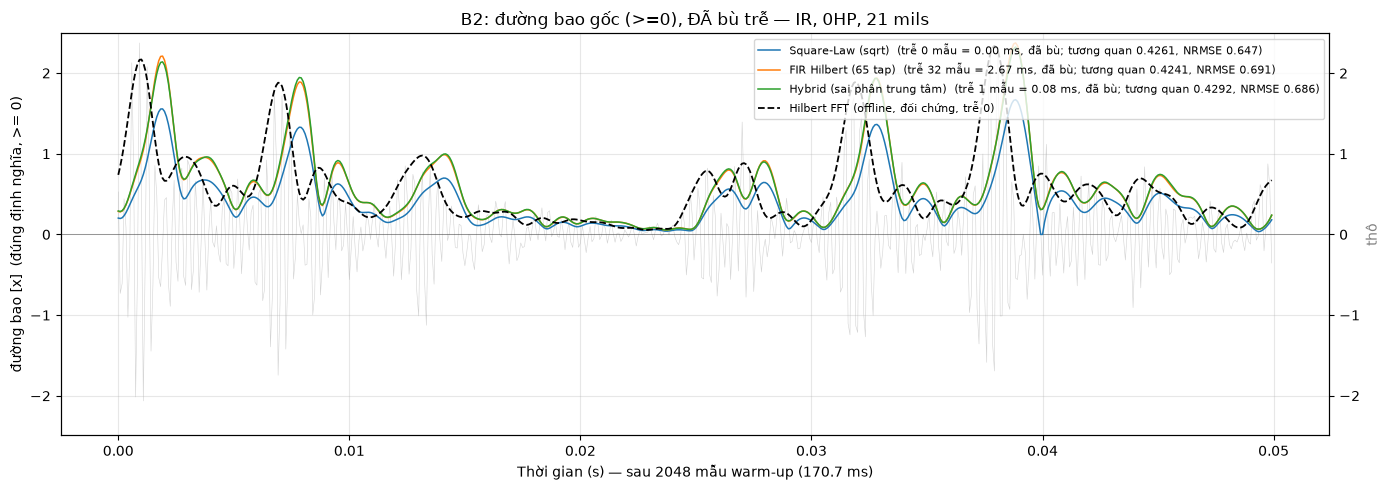

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0           0      1.6695     0.53344      0.4261   0.647
FIR Hilbert (65 tap)                32    0.055412      2.3732     0.74743      0.4241   0.691
Hybrid (sai phân trung tâm)          1    0.055557      2.3227      0.7492      0.4292   0.686


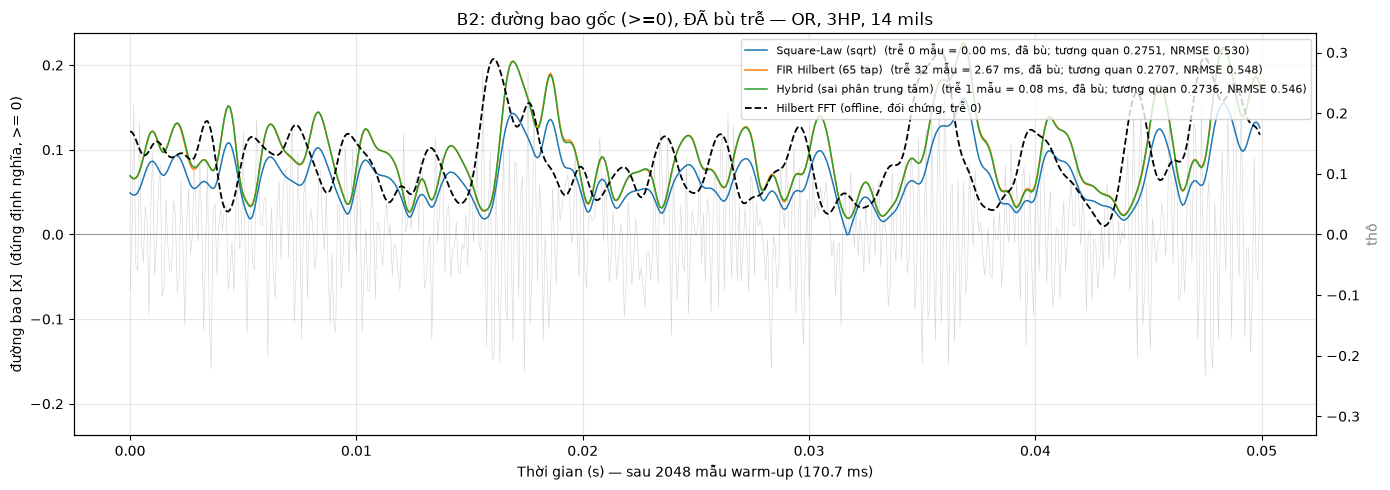

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0           0     0.16027    0.074739      0.2751   0.530
FIR Hilbert (65 tap)                32    0.019033      0.2262     0.10441      0.2707   0.548
Hybrid (sai phân trung tâm)          1    0.018777     0.22547     0.10419      0.2736   0.546


[('Square-Law (sqrt)',
  0,
  array([0.0489636 , 0.0471415 , 0.04636924, 0.04690499, 0.04938686,
         0.05364759, 0.05943268, 0.06628686, 0.07283128, 0.07901255,
         0.08343342, 0.0859702 , 0.08659551, 0.08467735, 0.08155647,
         0.07716588, 0.07290373, 0.07034686, 0.06961369, 0.07197813,
         0.0760987 , 0.08124841, 0.08641729, 0.090335  , 0.09280575,
         0.09311515, 0.09142899, 0.087836  , 0.08266749, 0.07654203,
         0.06995207, 0.06377652, 0.05861557, 0.05531386, 0.05418884,
         0.05492719, 0.0571781 , 0.05953131, 0.06161686, 0.06258386,
         0.0620454 , 0.06051405, 0.05766715, 0.05531088, 0.05418775,
         0.05601333, 0.0617891 , 0.07015953, 0.08064577, 0.09078893,
         0.09959307, 0.10579725, 0.10833475, 0.10725574, 0.10217175,
         0.09379744, 0.08299198, 0.07068653, 0.05846701, 0.04735207,
         0.03786475, 0.0305049 , 0.02439134, 0.01927371, 0.01830581,
         0.02178861, 0.03076691, 0.04207688, 0.05338914, 0.06464426,
      

In [15]:
# ---- BƯỚC 2: bù trễ nhóm (vẫn KHÔNG khử DC) ----
# So với B1 chỉ đổi align_delay -> mọi thay đổi của tương quan/NRMSE đều do
# ĐỘ TRỄ, không do gì khác. Kỳ vọng: FIR Hilbert cải thiện mạnh nhất vì nó
# trễ 32 mẫu (2.67 ms), Square-Law và Hybrid gần như không đổi (trễ 0 và 1).

plot_envelope_ablation('IR', 0, 21, '06_env_ab2_aligned_IR_0hp_21mils.png',
                       remove_dc=False, align_delay=True,
                       step_tag='B2: đường bao gốc (>=0), ĐÃ bù trễ')

plot_envelope_ablation('OR', 3, 14, '06_env_ab2_aligned_OR_3hp_14mils.png',
                       remove_dc=False, align_delay=True,
                       step_tag='B2: đường bao gốc (>=0), ĐÃ bù trễ')

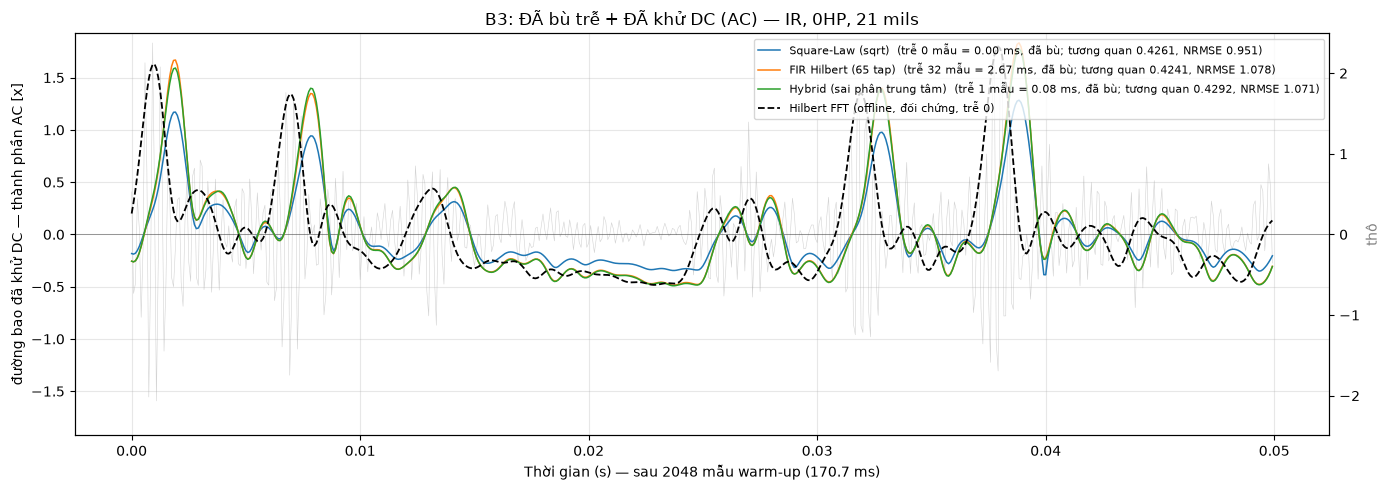

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0    -0.38558       1.284     0.34469      0.4261   0.951
FIR Hilbert (65 tap)                32    -0.48579       1.832     0.48193      0.4241   1.078
Hybrid (sai phân trung tâm)          1     -0.4911      1.7761     0.48002      0.4292   1.071


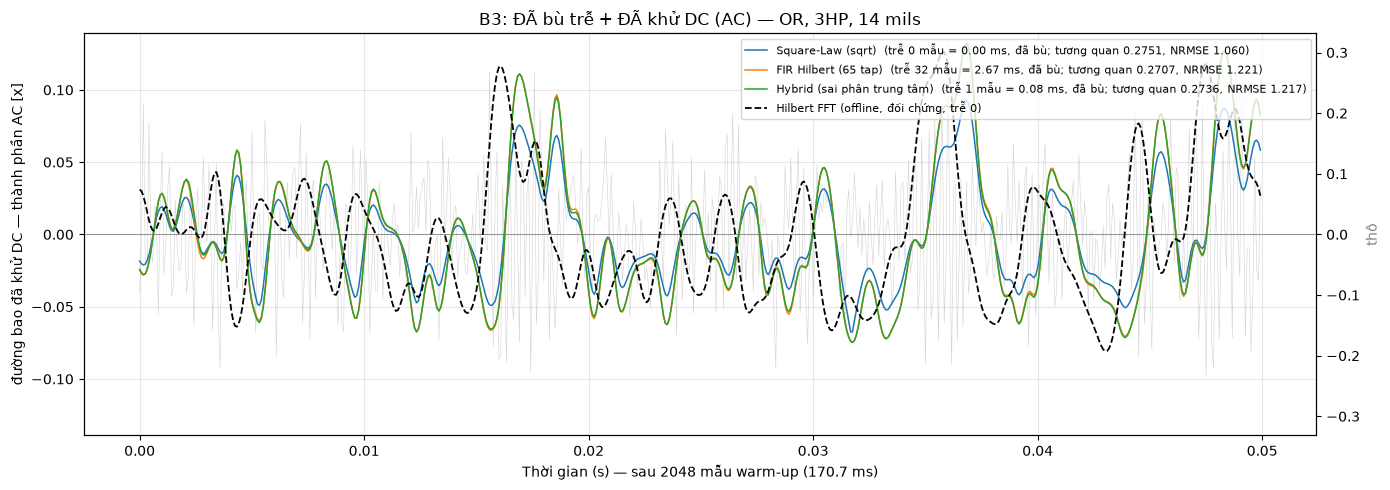

phương pháp                        trễ         min         max         RMS  tương quan   NRMSE
Square-Law (sqrt)                    0   -0.067472    0.092799    0.032908      0.2751   1.060
FIR Hilbert (65 tap)                32   -0.074676     0.13249    0.046602      0.2707   1.221
Hybrid (sai phân trung tâm)          1   -0.074774     0.13192    0.046511      0.2736   1.217


[('Square-Law (sqrt)',
  0,
  array([-1.85080415e-02, -2.03301423e-02, -2.11023994e-02, -2.05666502e-02,
         -1.80847751e-02, -1.38240431e-02, -8.03896167e-03, -1.18477460e-03,
          5.35963786e-03,  1.15409111e-02,  1.59617790e-02,  1.84985625e-02,
          1.91238744e-02,  1.72057084e-02,  1.40848328e-02,  9.69424482e-03,
          5.43209462e-03,  2.87522049e-03,  2.14205409e-03,  4.50649615e-03,
          8.62706612e-03,  1.37767763e-02,  1.89456547e-02,  2.28633667e-02,
          2.53341102e-02,  2.56435139e-02,  2.39573520e-02,  2.03643608e-02,
          1.51958542e-02,  9.07039679e-03,  2.48042882e-03, -3.69512220e-03,
         -8.85607268e-03, -1.21577758e-02, -1.32827963e-02, -1.25444503e-02,
         -1.02935401e-02, -7.94032382e-03, -5.85477306e-03, -4.88777933e-03,
         -5.42624002e-03, -6.95758594e-03, -9.80449268e-03, -1.21607548e-02,
         -1.32838883e-02, -1.14583116e-02, -5.68253669e-03,  2.68788836e-03,
          1.31741337e-02,  2.33172964e-02,  3.21

In [16]:
# ---- BƯỚC 3: bù trễ + KHỬ DC (đúng thứ pipeline đang dùng) ----
# So với B2 chỉ đổi remove_dc -> cô lập tác dụng của khử DC.
# KIỂM TRA CHÉO: tương quan phải TRÙNG KHÍT B2 (Pearson bất biến với dịch
# DC); chỉ NRMSE được phép đổi. Nếu tương quan lệch -> có lỗi.

plot_envelope_ablation('IR', 0, 21, '06_env_ab3_dc_removed_IR_0hp_21mils.png',
                       remove_dc=True, align_delay=True,
                       step_tag='B3: ĐÃ bù trễ + ĐÃ khử DC (AC)')

plot_envelope_ablation('OR', 3, 14, '06_env_ab3_dc_removed_OR_3hp_14mils.png',
                       remove_dc=True, align_delay=True,
                       step_tag='B3: ĐÃ bù trễ + ĐÃ khử DC (AC)')

In [17]:
# ===== 4c. PHỔ ENVELOPE theo từng phương pháp — đánh dấu tần số lỗi lý thuyết =====
# Dùng lại envelope_of() và WARMUP/FS_COL đã định nghĩa ở cell 4b, nên cell này
# PHẢI chạy sau cell 4b.
from common import order

SPEC_METHODS = [
    ('Square-Law (sqrt)',                 'square_law',      'tab:blue'),
    ('FIR Hilbert (65 tap)',              'hilbert_fir',     'tab:orange'),
    ('Hybrid (sai phân trung tâm)',       'hybrid',          'tab:green'),
    ('Hilbert FFT (offline, đối chứng)',  'hilbert_offline', 'black'),
]

# Mỗi họ tần số một màu riêng; hài bậc 1 vẽ nét liền, bậc 2-3 nét đứt/chấm.
FAULT_COLORS = {
    'BPFO':  'tab:red',
    'BPFI':  'tab:purple',
    'BSF':   'tab:brown',
    'FTF':   'tab:cyan',
    'f_rot': 'dimgray',
}
FAULT_NAMES = ('BPFO', 'BPFI', 'BSF', 'FTF')
HARM_STYLE = {1: '-', 2: '--', 3: ':'}
FMAX_PLOT = 500.0      # đủ chứa hài bậc 3 của BPFI (~487 Hz @0HP)
SPEC_WINDOW = True     # cửa sổ Hann trước FFT để giảm rò rỉ phổ
SEARCH_WIDTH_HZ = 3.0  # nửa bề rộng cửa sổ dò đỉnh quanh tần số lý thuyết

In [18]:
def rpm_of_row(row):
    """
    rpm THỰC của file nếu .mat có biến rpm, nếu không thì rpm danh định
    theo tải (cfg.NOMINAL_RPM_BY_LOAD) — không hard-code con số nào.
    """
    rpm = row.get('rpm_from_file')
    if rpm is None or pd.isna(rpm):
        return float(cfg.NOMINAL_RPM_BY_LOAD[int(row['load_hp'])])
    return float(rpm)


def plot_envelope_spectrum(label, load_hp, diameter_mils, out_name,
                           remove_dc=True, fmax_hz=FMAX_PLOT,
                           harmonics=(1, 2, 3)):
    """
    Phổ envelope của từng phương pháp, MỖI PHƯƠNG PHÁP MỘT SUBPLOT.
    Chuỗi xử lý mỗi phương pháp (đúng thứ pipeline dùng):
    envelope toàn file -> bỏ WARMUP + trễ nhóm riêng của phương pháp
    -> giảm mẫu bằng dsp.decimate_envelope (1/ENV_DECIM) -> khử trung bình
    -> FFT (Hann) -> chuẩn hóa theo đỉnh lớn nhất trong 0..fmax_hz.
    Chuẩn hóa từng phương pháp theo chính nó để so ĐƯỢC chéo dù Square-Law,
    Hilbert và Hybrid có thang biên độ khác nhau.
    """
    file_path = pick_file(manifest, label=label, load_hp=load_hp,
                          diameter_mils=diameter_mils)
    row = manifest.loc[manifest['file_path'] == file_path].iloc[0]
    source_fs = float(row[FS_COL])
    fs_file = float(FS)
    rpm = rpm_of_row(row)
    faults = cfg.bearing_fault_frequencies(rpm)

    x_full = np.asarray(
        io_utils.load_de_signal_resampled(Path(file_path), source_fs, fs_file),
        dtype=np.float64,
    )
    print(f'[Phổ envelope] {Path(file_path).name} | {label}, {load_hp}HP, '
          f'{diameter_mils} mils | fs nguồn = {source_fs:.0f} Hz '
          f'-> fs xử lý = {fs_file:.0f} Hz | {len(x_full)} mẫu | '
          f'rpm = {rpm:.0f} -> f_rot = {rpm / 60.0:.2f} Hz')
    print('  Tần số lý thuyết (Hz): ' + ', '.join(
          f'{k} = {faults[k]:.2f}' for k in ('f_rot',) + FAULT_NAMES))

    specs = []
    for name, key, col in SPEC_METHODS:
        d = dsp.envelope_group_delay(key)
        env = np.asarray(envelope_of(x_full, key, remove_dc), dtype=np.float64)
        env = env[WARMUP + d:]
        env_d, fs_env = dsp.decimate_envelope(env, fs_file)
        env_d = env_d - np.mean(env_d)
        freqs, mag = dsp.compute_fft(env_d, fs_env, apply_window=SPEC_WINDOW)
        band = (freqs > 0.0) & (freqs <= fmax_hz)
        peak = float(np.max(mag[band])) if band.any() else 1.0
        specs.append((name, key, col, freqs, mag / (peak + 1e-20), fs_env, len(env_d)))

    df_hz = specs[0][5] / specs[0][6]
    fig, axes = plt.subplots(len(specs), 1, figsize=(14, 3.1 * len(specs)),
                             sharex=True)

    for ax, (name, key, col, freqs, mag_n, fs_env, n_env) in zip(axes, specs):
        band = freqs <= fmax_hz
        ax.plot(freqs[band], mag_n[band], linewidth=0.9, color=col, zorder=3)

        for fname in FAULT_NAMES:
            for h in harmonics:
                f_line = faults[fname] * h
                if f_line > fmax_hz:
                    continue
                ax.axvline(f_line, color=FAULT_COLORS[fname],
                           linestyle=HARM_STYLE.get(h, ':'),
                           linewidth=1.1 if h == 1 else 0.9,
                           alpha=0.85 if h == 1 else 0.6, zorder=2,
                           label=f'{fname} h{h} = {f_line:.1f} Hz'
                           if ax is axes[0] else None)

        f_rot = faults['f_rot']
        if f_rot <= fmax_hz:
            ax.axvline(f_rot, color=FAULT_COLORS['f_rot'], linestyle='-.',
                       linewidth=0.8, alpha=0.7, zorder=2,
                       label=f'f_rot = {f_rot:.1f} Hz' if ax is axes[0] else None)

        ax.set_ylabel('|FFT| chuẩn hóa')
        ax.set_ylim(0.0, 1.05)
        ax.set_xlim(0.0, fmax_hz)
        ax.grid(alpha=0.3)
        ax.set_title(f'{name} — fs envelope = {fs_env:.0f} Hz, '
                     f'{n_env} mẫu, độ phân giải {fs_env / n_env:.2f} Hz/bin',
                     fontsize=10, loc='left')

    axes[0].legend(loc='upper right', fontsize=7, ncol=2)
    axes[-1].set_xlabel('Tần số (Hz) — phổ của ĐƯỜNG BAO, không phải phổ tín hiệu thô')
    fig.suptitle(f'Phổ envelope theo phương pháp — {label}, {load_hp}HP, '
                 f'{diameter_mils} mils (rpm = {rpm:.0f})', fontsize=12)
    fig.tight_layout()
    fig.subplots_adjust(top=0.94)
    plt.savefig(FIGURES_DIR / out_name, dpi=150)
    plt.show()

    rows_out = []
    for name, key, col, freqs, mag_n, fs_env, n_env in specs:
        rec = {'phuong_phap': name}
        for fname in FAULT_NAMES:
            for h in harmonics:
                rec[f'{fname}_h{h}'] = round(order.amplitude_near_frequency(
                    freqs, mag_n, faults[fname] * h,
                    search_width_hz=SEARCH_WIDTH_HZ), 4)
        rows_out.append(rec)

    spec_df = pd.DataFrame(rows_out)
    csv_name = out_name.replace('.png', '.csv')
    spec_df.to_csv(TABLES_DIR / csv_name, index=False)

    print(f'\nBiên độ chuẩn hóa tại tần số lỗi lý thuyết '
          f'(cửa sổ dò +/-{SEARCH_WIDTH_HZ} Hz, 1 bin = {df_hz:.2f} Hz):')
    print(spec_df.to_string(index=False))
    print(f'-> đã ghi {TABLES_DIR / csv_name}')

    return spec_df

[Phổ envelope] 209_0.mat | IR, 0HP, 21 mils | fs nguồn = 12000 Hz -> fs xử lý = 12000 Hz | 122136 mẫu | rpm = 1797 -> f_rot = 29.95 Hz
  Tần số lý thuyết (Hz): f_rot = 29.95, BPFO = 107.36, BPFI = 162.19, BSF = 70.58, FTF = 11.93


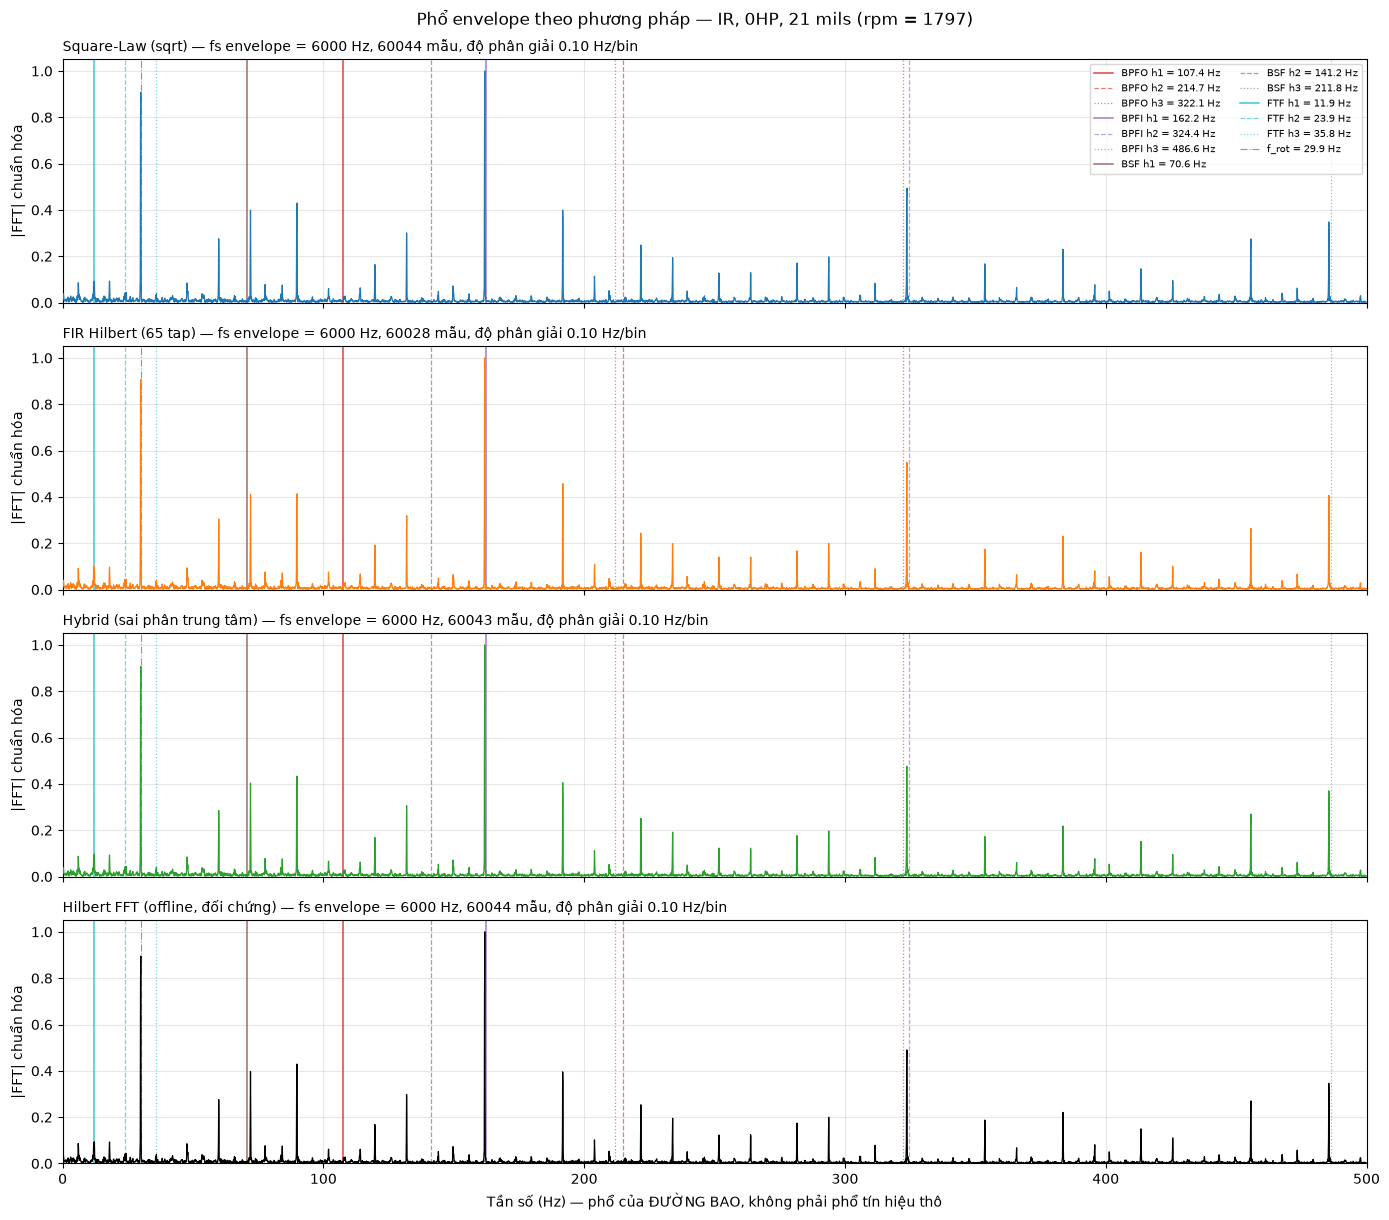


Biên độ chuẩn hóa tại tần số lỗi lý thuyết (cửa sổ dò +/-3.0 Hz, 1 bin = 0.10 Hz):
                     phuong_phap  BPFO_h1  BPFO_h2  BPFO_h3  BPFI_h1  BPFI_h2  BPFI_h3  BSF_h1  BSF_h2  BSF_h3  FTF_h1  FTF_h2  FTF_h3
               Square-Law (sqrt)   0.0283   0.0237   0.4938      1.0   0.4938   0.3484  0.3988  0.0489  0.0516  0.0917  0.0444  0.0384
            FIR Hilbert (65 tap)   0.0303   0.0259   0.5494      1.0   0.5494   0.4066  0.4119  0.0505  0.0485  0.0992  0.0452  0.0397
     Hybrid (sai phân trung tâm)   0.0290   0.0231   0.4750      1.0   0.4750   0.3703  0.4036  0.0534  0.0521  0.0964  0.0434  0.0404
Hilbert FFT (offline, đối chứng)   0.0283   0.0239   0.4902      1.0   0.4902   0.3459  0.3972  0.0516  0.0528  0.0933  0.0435  0.0387
-> đã ghi outputs\tables\06_env_spectrum_IR_0hp_21mils.csv
[Phổ envelope] 200@6_3.mat | OR, 3HP, 14 mils | fs nguồn = 12000 Hz -> fs xử lý = 12000 Hz | 121991 mẫu | rpm = 1723 -> f_rot = 28.72 Hz
  Tần số lý thuyết (Hz): f_rot = 28.72, BPFO 

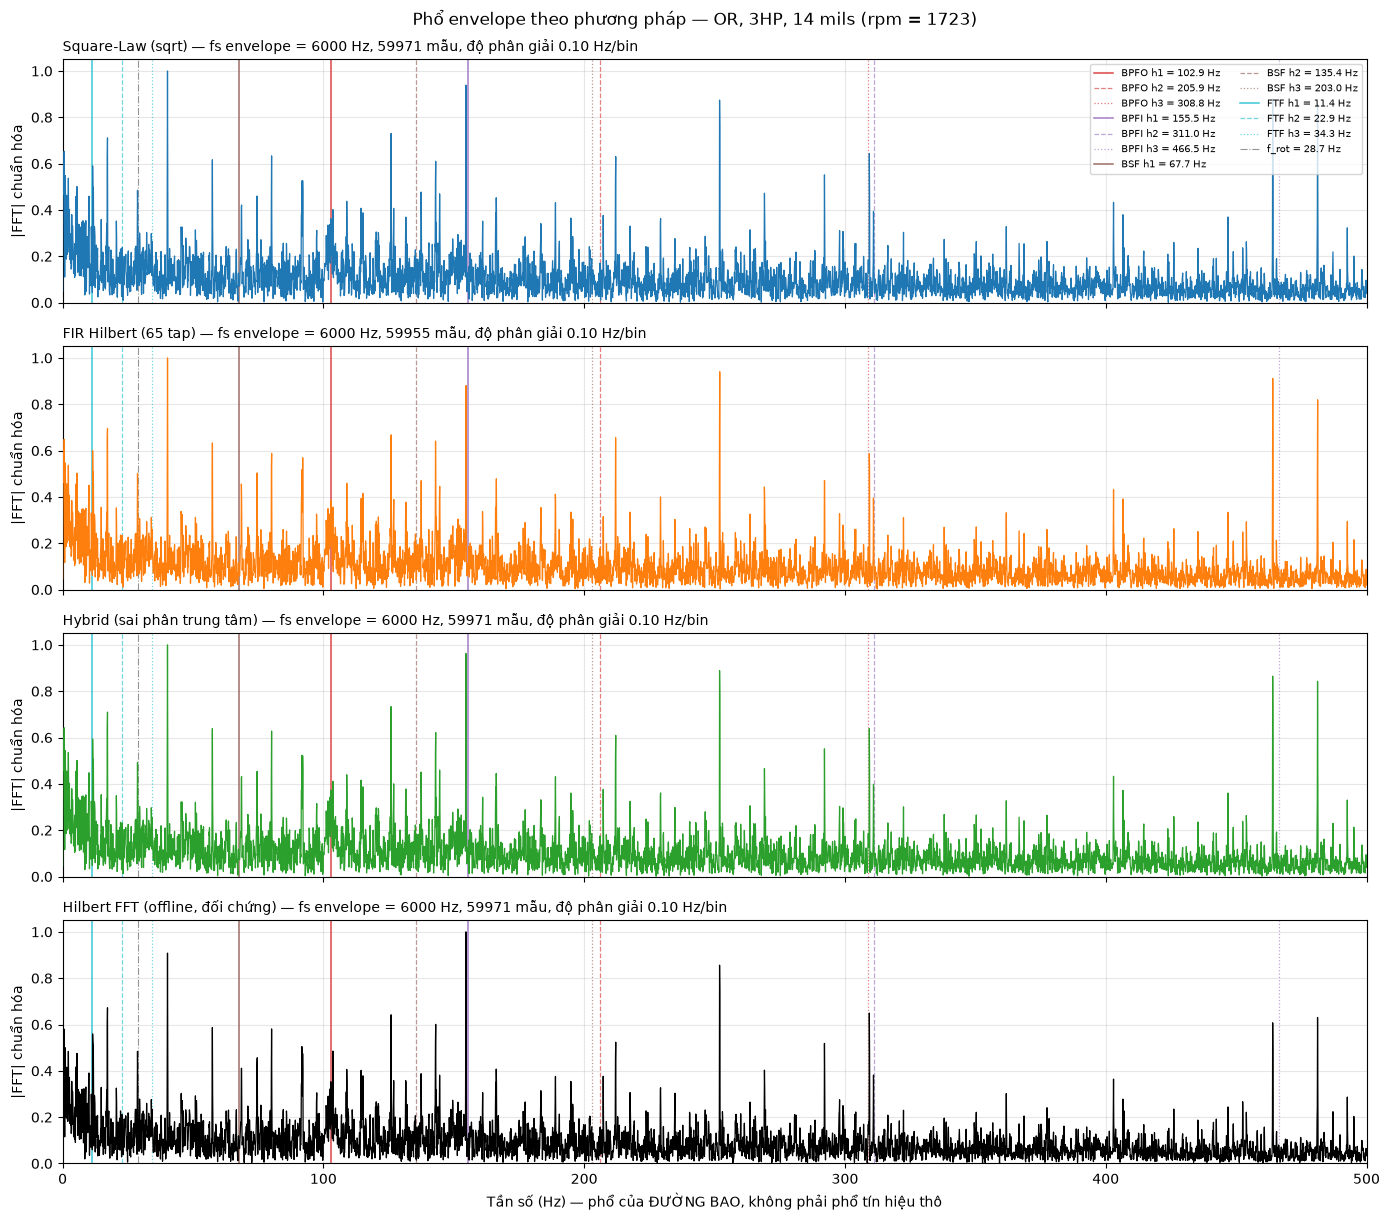


Biên độ chuẩn hóa tại tần số lỗi lý thuyết (cửa sổ dò +/-3.0 Hz, 1 bin = 0.10 Hz):
                     phuong_phap  BPFO_h1  BPFO_h2  BPFO_h3  BPFI_h1  BPFI_h2  BPFI_h3  BSF_h1  BSF_h2  BSF_h3  FTF_h1  FTF_h2  FTF_h3
               Square-Law (sqrt)   0.4015   0.3763   0.6435   0.9385   0.6435   0.8788  0.4213  0.4773  0.2412  0.5905  0.3523  0.3031
            FIR Hilbert (65 tap)   0.3848   0.3154   0.5863   0.8808   0.5863   0.9115  0.4557  0.4701  0.2191  0.5995  0.3526  0.3118
     Hybrid (sai phân trung tâm)   0.4114   0.3761   0.6388   0.9628   0.6388   0.8650  0.4321  0.4511  0.2408  0.5937  0.3490  0.2968
Hilbert FFT (offline, đối chứng)   0.4854   0.3765   0.6495   1.0000   0.6495   0.6074  0.4111  0.3876  0.2044  0.5593  0.3253  0.2760
-> đã ghi outputs\tables\06_env_spectrum_OR_3hp_14mils.csv


In [19]:
spec_ir = plot_envelope_spectrum('IR', 0, 21, '06_env_spectrum_IR_0hp_21mils.png',
                                 remove_dc=True)

spec_or = plot_envelope_spectrum('OR', 3, 14, '06_env_spectrum_OR_3hp_14mils.png',
                                 remove_dc=True)

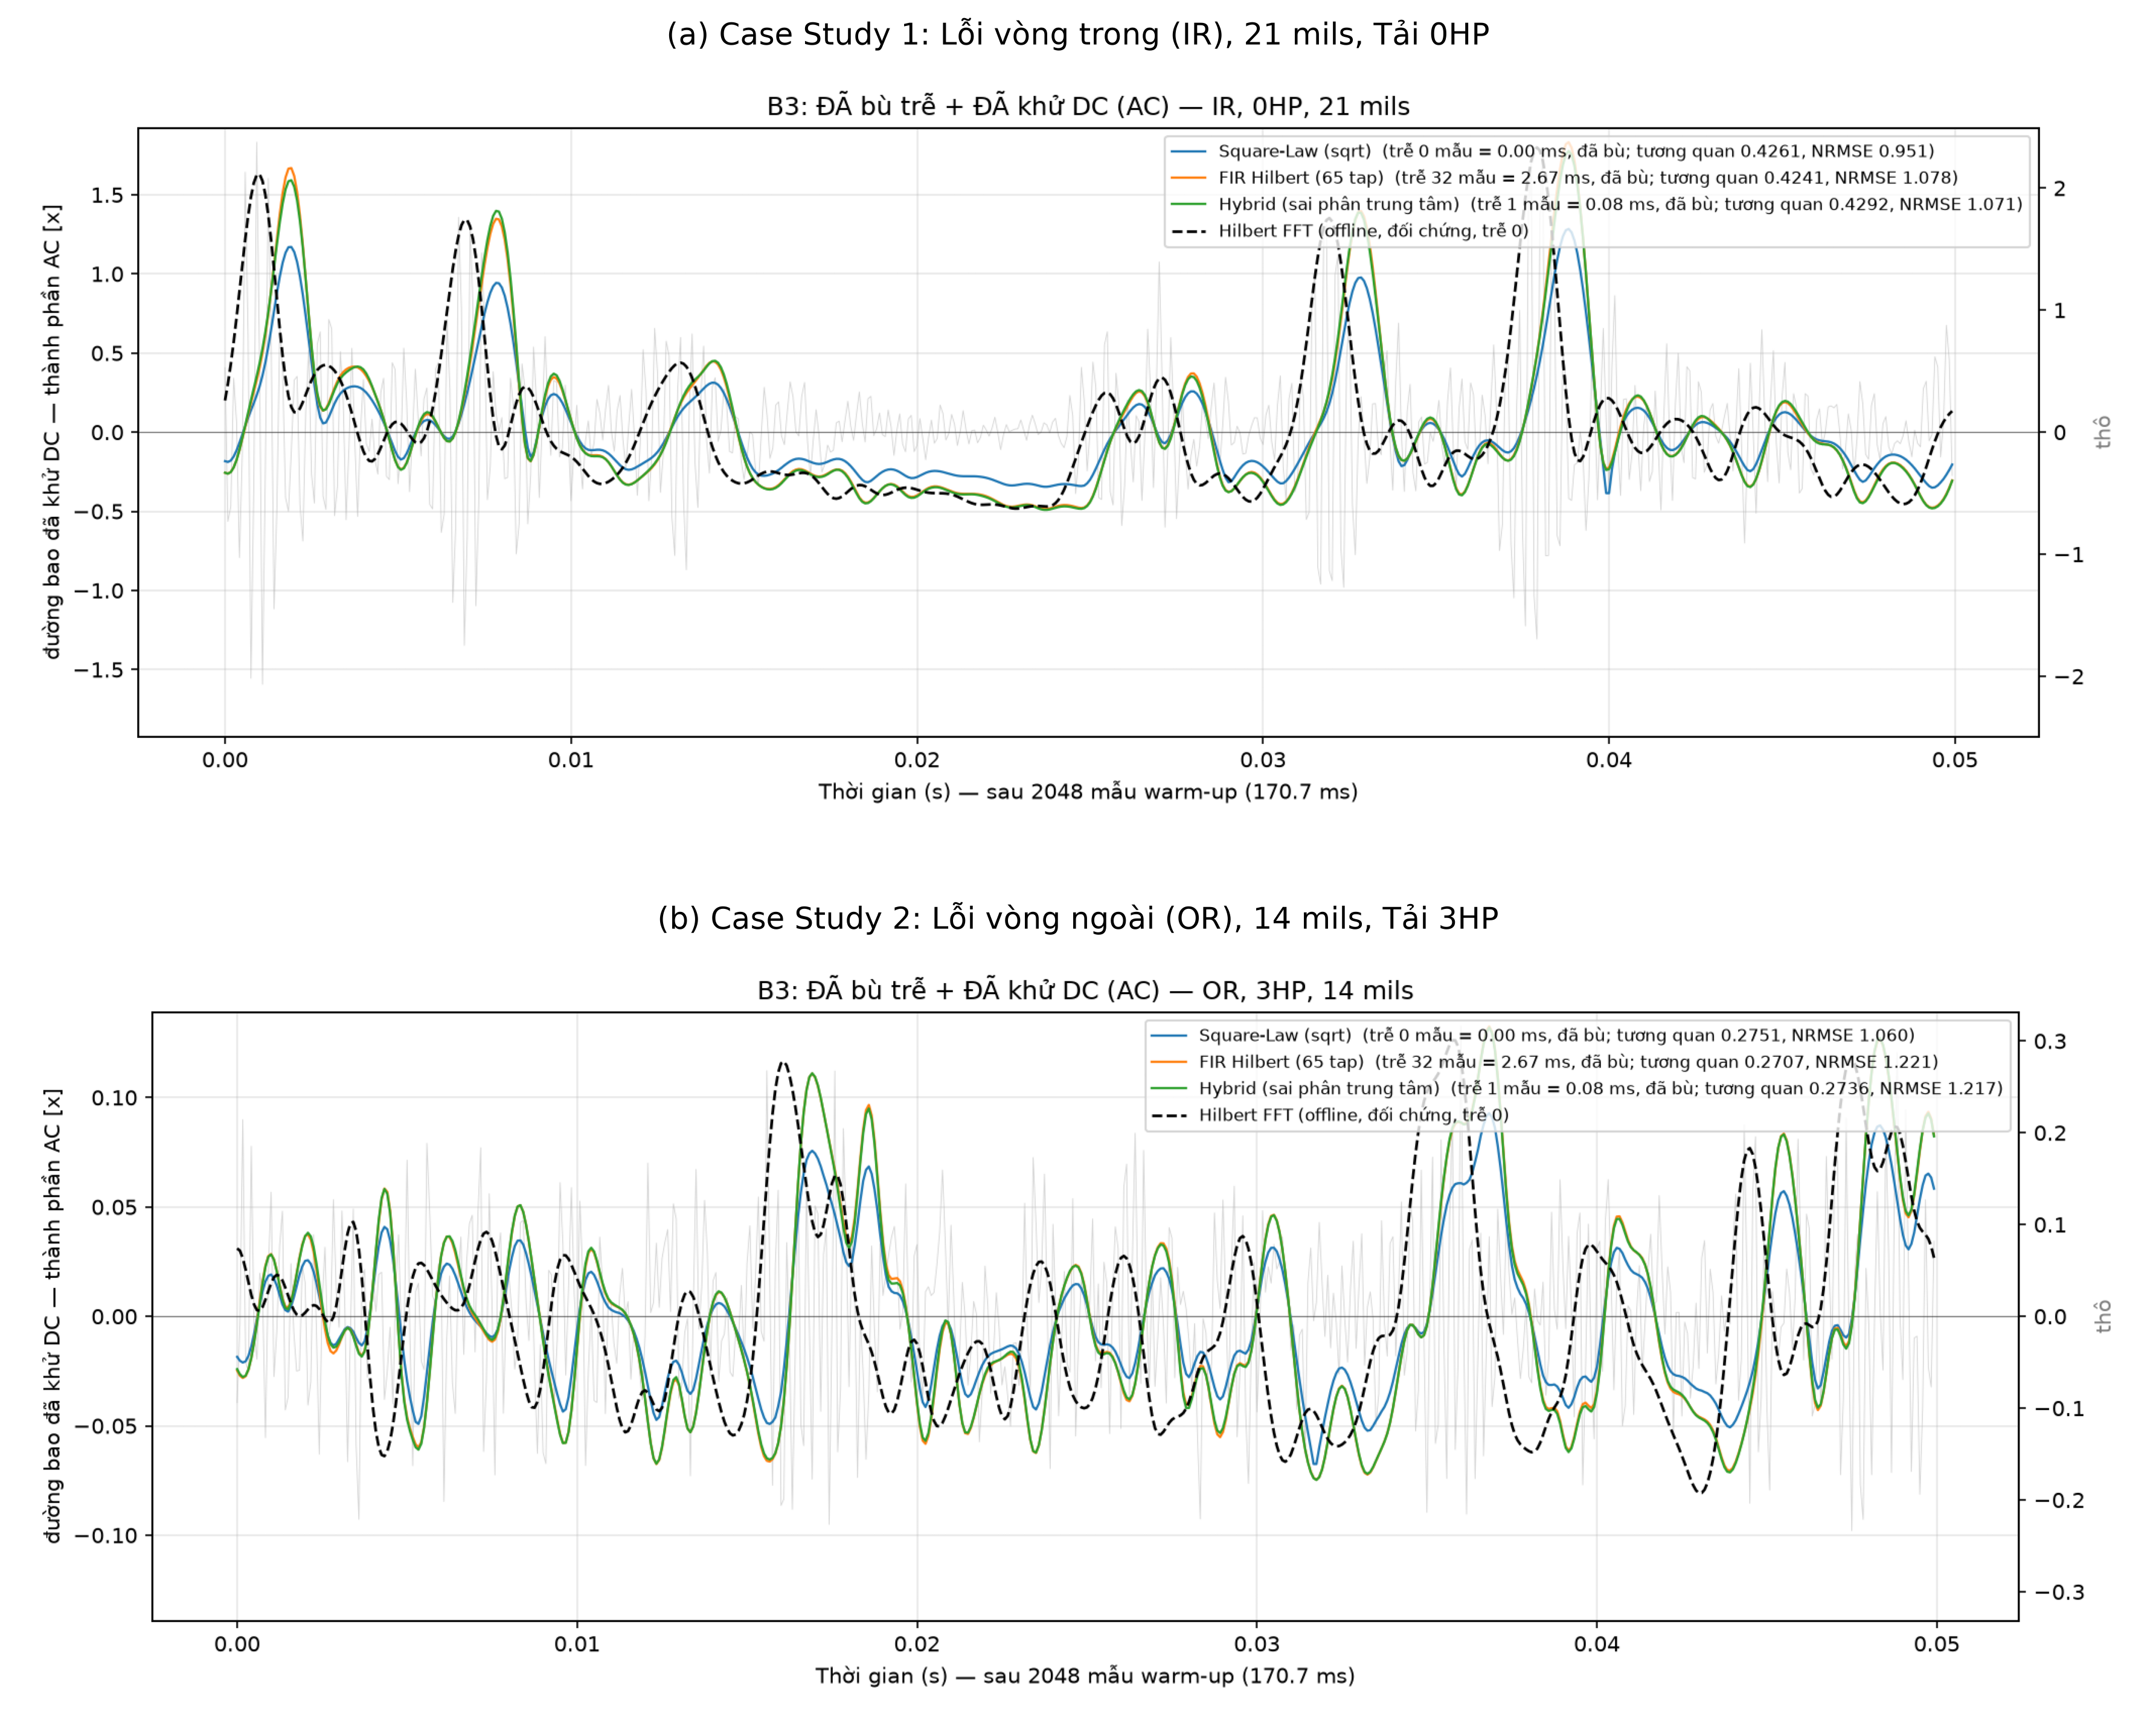

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Đảm bảo đường dẫn file chính xác với thư mục của bạn
img_ir = mpimg.imread(FIGURES_DIR / '06_env_ab3_dc_removed_IR_0hp_21mils.png')
img_or = mpimg.imread(FIGURES_DIR / '06_env_ab3_dc_removed_OR_3hp_14mils.png')

fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=300)

axes[0].imshow(img_ir)
axes[0].axis('off')
axes[0].set_title('(a) Case Study 1: Lỗi vòng trong (IR), 21 mils, Tải 0HP', fontsize=12, pad=10)

axes[1].imshow(img_or)
axes[1].axis('off')
axes[1].set_title('(b) Case Study 2: Lỗi vòng ngoài (OR), 14 mils, Tải 3HP', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_composite_env_ablation_B3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Cấu hình tham số đã chốt

Tất cả nằm trong **một** file `outputs/tables/bandpass_config.json`, do notebook 03 ghi ra và notebook 04/05/06 đọc lại. Không notebook nào gõ lại hằng số, nên không thể có hai giá trị lệch nhau giữa các bước.

| Tham số | Giá trị đã chốt |
|---|---|
| Dải bandpass | 2300–3800 Hz, Butterworth bậc 4, nhân quả |
| Tần số trung tâm f_c | 3050 Hz, sát fs/4 = 3000 Hz |
| Lowpass envelope | 750 Hz, Butterworth bậc 2 |
| Tần số lấy mẫu | 12 000 Hz, cảm biến DE |
| Cửa sổ raw / bước nhảy | 2048 / 1024 mẫu |
| Envelope sau giảm mẫu | 1/2 → 6000 Hz, cửa sổ 1024 / bước 512 |
| Bỏ đầu file | 2048 mẫu |
| Độ phân giải phổ | 5.86 Hz mỗi bin |
| FIR Hilbert | 65 tap, trễ nhóm 32 mẫu |
| Alpha-Max Plus Beta-Min | alpha = 0.947, beta = 0.392 |

## Toàn bộ sản phẩm giai đoạn 1

| # | Sản phẩm | File | Notebook |
|---|---|---|---|
| 1 | Manifest đã lọc và kiểm định | `manifest.csv`, `manifest_filtered.csv`, `manifest_clean.csv` | 01, 02 |
| 2 | Bảng đặc trưng MLP, 28 đặc trưng, 4623 cửa sổ | `features_mlp_squarelaw.parquet`, `features_mlp_hilbert.parquet`, `features_mlp_hybrid.parquet` | 04 |
| 3 | Dữ liệu chuỗi cho 1D CNN | `windows_cnn_raw.parquet`, `windows_cnn_env_*.parquet`, `windows_cnn_config.json` | 05 |
| 4 | DSP: pha, biên độ, dạng sóng đường bao | `06_iq_phase_amplitude.csv`, `06_envelope_waveform.png` | 06 |
| 5 | Cấu hình tham số đã chốt | `bandpass_config.json` | 03 |